In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
class Lor_reservoir:
    def __init__(self, hyperparameters):
        self.num_neurons = hyperparameters.get("num_neurons")
        self.input_connectivity = hyperparameters.get("input_connectivity")
        self.num_steps = hyperparameters.get("num_steps")
        self.input_firing_rate = hyperparameters.get("input_firing_rate")
        self.weight_connectivity = hyperparameters.get("weight_connectivity")
        self.LIF_beta = hyperparameters.get("LIF_beta")
        self.LIF_threshold = hyperparameters.get("LIF_threshold")
        

    def init_weights(self):

        # weight matrix for reservoir. Weights drawn from gaussian with mean 0 and std 0.333s, and with 10% connectivity.
        # includes exitatory and inhibitory weights.
        w_res = np.random.normal(0, 0.333, (self.num_neurons, self.num_neurons))

        mask = np.random.rand(self.num_neurons, self.num_neurons) < self.weight_connectivity
        w_res = w_res * mask
        np.fill_diagonal(w_res, 0) # no self-connections

        eigenvalues = np.linalg.eigvals(w_res)
        current_sr = np.max(np.abs(eigenvalues))
        # optimal spectral radius
        target_sr = 0.9

        #TODO more on this
        if current_sr > 0: 
            w_res = w_res / current_sr * target_sr

        return w_res
        

    def init_input_weights_full(self, input_dim):
        # shape: (num_neurons, input_dim)
        # random signs and magnitudes, sparse by input_connectivity
        w_in = np.random.uniform(-1, 1, (self.num_neurons, input_dim))
        mask = np.zeros((self.num_neurons, input_dim))
        input_neurons = np.random.choice(
            self.num_neurons,
            size=int(self.num_neurons * self.input_connectivity),
            replace=False
        )
        mask[input_neurons, :] = 1.0
        return w_in * mask

    def gen_spikes(self, rate_tensor):
        random_vals = np.random.random(rate_tensor.shape)
        spikes = (random_vals < rate_tensor).astype(float)
        return spikes
    

    def LIF_res(self, prev_mem, prev_spk, w_res, input, beta, threshold):

        recurrent_input = w_res @ prev_spk  # (num_neurons,)
        
        total_input = input + recurrent_input # (num_neurons,)

        spk = (prev_mem > threshold).astype(float)
        mem = beta * prev_mem + total_input - spk * threshold
        
        return mem, spk

In [19]:
def generate_lorenz(num_steps, dt=0.01, sigma=10, rho=28, beta=8/3):
    xyz = np.zeros((num_steps, 3))
    xyz[0] = [1.0, 1.0, 1.0]  # initial condition
    for t in range(num_steps - 1):
        x, y, z = xyz[t]
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        xyz[t+1] = xyz[t] + dt * np.array([dx, dy, dz])
    return xyz

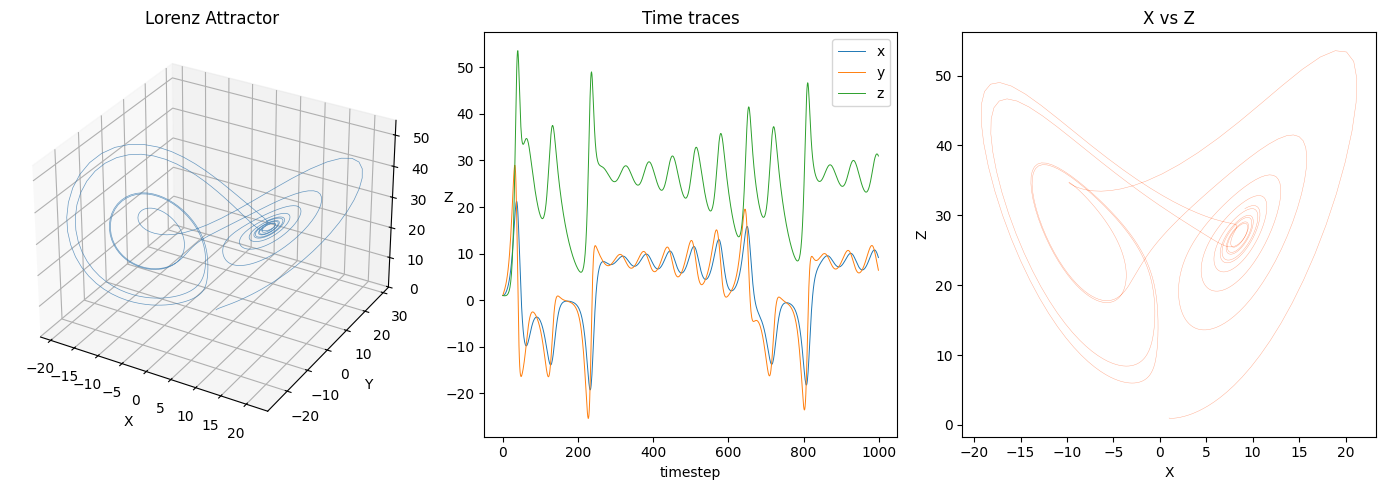

In [20]:
def plot_lorenz(lorenz_traj):
    x, y, z = lorenz_traj[:,0], lorenz_traj[:,1], lorenz_traj[:,2]
    
    fig = plt.figure(figsize=(14, 5))
    
    # 3D butterfly
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.plot(x, y, z, lw=0.5, alpha=0.8, color='steelblue')
    ax1.set_title('Lorenz Attractor')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    
    # time traces
    ax2 = fig.add_subplot(132)
    t = np.arange(len(x))
    ax2.plot(t, x, lw=0.7, label='x')
    ax2.plot(t, y, lw=0.7, label='y')
    ax2.plot(t, z, lw=0.7, label='z')
    ax2.set_title('Time traces')
    ax2.set_xlabel('timestep')
    ax2.legend()
    
    # x vs z (one lobe visible)
    ax3 = fig.add_subplot(133)
    ax3.plot(x, z, lw=0.3, alpha=0.7, color='coral')
    ax3.set_title('X vs Z')
    ax3.set_xlabel('X'); ax3.set_ylabel('Z')
    
    plt.tight_layout()
    plt.show()

lorenz_traj = generate_lorenz(1000, dt=0.01) # (num_steps, 3)
plot_lorenz(lorenz_traj)

In [ ]:
def train_readout_ridge(X_train, Y_train, alpha=1e-4):

    # X_train: (T, N)
    # Y_train: (T, 3)
    T, N = X_train.shape
    w_out = Y_train.T @ X_train @ np.linalg.inv(X_train.T @ X_train + alpha * np.eye(N))
    return w_out  # (3, N)

In [22]:
def train_readout_lstsq(X_train, Y_train):
    # X_train: (N, T), Y_train: (3, T)
    N = X_train.shape[0]
    w_out = Y_train @ X_train.T @ np.linalg.inv(X_train @ X_train.T)
    return w_out  # (3, N)

In [ ]:
washout_steps = 200
train_steps   = 700
test_steps    = 300
total_steps   = washout_steps + train_steps + test_steps  # 1200


hp = {
    "num_steps": total_steps,
    "num_neurons": 100,
    "input_firing_rate": 0.4,
    "input_connectivity": 0.3,
    "weight_connectivity": 0.1,
    "LIF_beta": 0.8187,
    "LIF_threshold": 1.0,
}


num_neurons = hp['num_neurons']
num_steps = hp['num_steps']


res = Lor_reservoir(hp)
w_in_weights = res.init_input_weights_full(3) # (num_neurons, 3)
w_res = res.init_weights()

lorenz_traj = generate_lorenz(num_steps, dt=0.01) # (num_steps, 3)


mem = np.zeros(num_neurons)
spk = np.zeros(num_neurons)
spk_rec = np.zeros((num_steps, num_neurons))
mem_rec = np.zeros((num_steps, num_neurons))



for t in range(num_steps):

    
    I = w_in_weights @ lorenz_traj[t] # (100, )

    mem, spk = res.LIF_res(mem, spk, w_res, I, hp["LIF_beta"], hp["LIF_threshold"])
    spk_rec[t] = spk
    mem_rec[t] = mem


X_train = spk_rec[washout_steps : washout_steps + train_steps]    # (T, N)
Y_train = lorenz_traj[washout_steps+1 : washout_steps + train_steps+1]  # (T, 3)



w_out = train_readout_ridge(X_train, Y_train, alpha=1e-4)  # (3, N)


X_test = spk_rec[washout_steps + train_steps : total_steps - 1]   # (T, N)
Y_test = lorenz_traj[washout_steps + train_steps+1 : total_steps]  # (T, 3)

Y_pred = (w_out @ X_test.T).T   # (T, 3)


def nrmse(y_true, y_pred):
    # y_true, y_pred: (3, T)
    error = np.sqrt(np.mean((y_true - y_pred)**2, axis=1))
    scale = np.std(y_true, axis=1)
    return error / scale  # (3,) — one per coordinate

scores = nrmse(Y_test, Y_pred)
print(f"NRMSE  x:{scores[0]:.3f}  y:{scores[1]:.3f}  z:{scores[2]:.3f}")

NRMSE  x:0.442  y:0.206  z:0.282


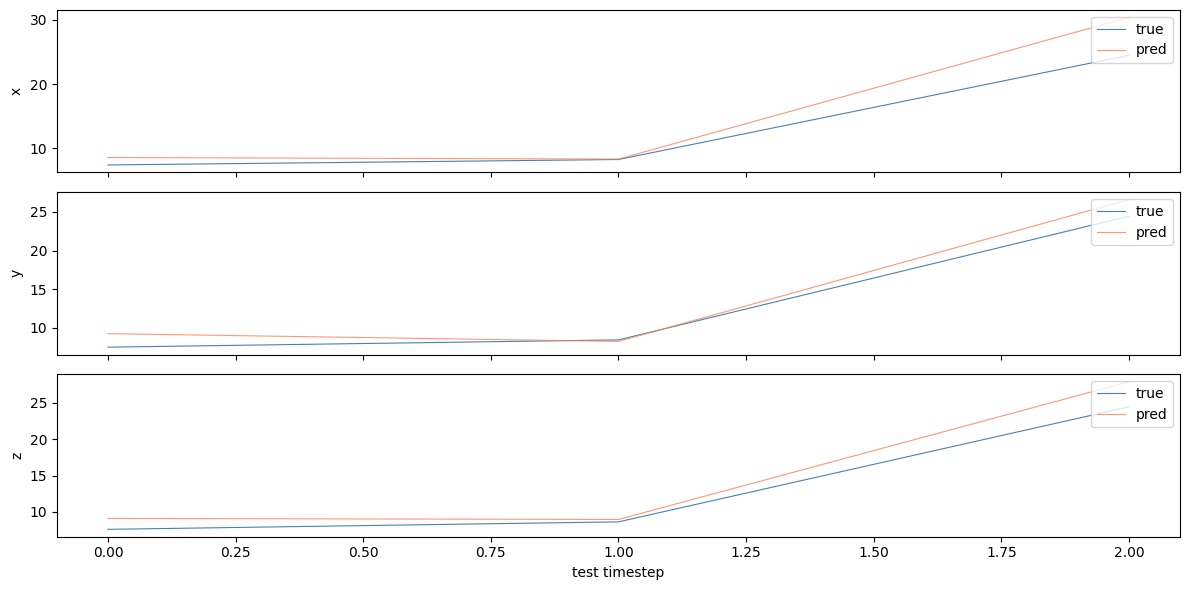

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
labels = ['x', 'y', 'z']
for i, ax in enumerate(axes):
    ax.plot(Y_test[i], lw=0.8, label='true', color='steelblue')
    ax.plot(Y_pred[i], lw=0.8, label='pred', color='coral', alpha=0.8)
    ax.set_ylabel(labels[i])
    ax.legend(loc='upper right')
axes[-1].set_xlabel('test timestep')
plt.tight_layout()
plt.show()